# MAE Linear Probe — Binary Embryo Viability

Freezes the MAE encoder, trains a single linear layer on top.

Expected folder structure:
```
labelled_embryos/
    viable/
        img001.jpg
        img002.jpg
    non_viable/
        img003.jpg
```

In [ ]:
!pip install transformers scikit-learn matplotlib seaborn --quiet

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from transformers import ViTMAEModel

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class CFG:
    # ── Paths ──────────────────────────────────────────────────
    # Root folder containing two subfolders: viable/ and non_viable/
    DATA_DIR      = "/content/drive/MyDrive/embryo_dataset_looklike/labelled_embryos/fine_tuned_labeled"
    ENCODER_PATH  = "/content/drive/MyDrive/embryo_mae/embryo_mae_encoder.pth"
    SAVE_DIR      = "/content/drive/MyDrive/embryo_mae/classifier"

    # ── Classes (order matters — index 0 = negative class) ────
    CLASSES       = ["non_viable", "viable"]   # folder names

    # ── Training ───────────────────────────────────────────────
    IMAGE_SIZE    = 224
    BATCH_SIZE    = 32
    EPOCHS        = 30
    LR            = 1e-5          # higher LR is fine — only the head trains
    WEIGHT_DECAY  = 1e-4
    VAL_SPLIT     = 0.2           # 80/20 train/val split
    TEST_SPLIT    = 0.1           # held-out test set
    NUM_WORKERS   = 2
    DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
    SEED          = 42

os.makedirs(CFG.SAVE_DIR, exist_ok=True)
torch.manual_seed(CFG.SEED)
print("DEVICE:", CFG.DEVICE)

DEVICE: cuda


## 1. Dataset

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


class EmbryoDataset(Dataset):
    def __init__(self, data_dir, classes, transform=None):
        self.transform = transform
        self.samples   = []   # (path, label_int)
        self.classes   = classes

        valid_ext = {".jpg", ".jpeg", ".png", ".bmp"}
        for label_idx, class_name in enumerate(classes):
            folder = os.path.join(data_dir, class_name)
            if not os.path.isdir(folder):
                raise FileNotFoundError(
                    f"Expected folder not found: {folder}\n"
                    f"Make sure CFG.CLASSES matches your actual folder names."
                )
            for fname in os.listdir(folder):
                if os.path.splitext(fname.lower())[1] in valid_ext:
                    self.samples.append(
                        (os.path.join(folder, fname), label_idx)
                    )

        print(f"Found {len(self.samples)} images across {len(classes)} classes")
        for i, c in enumerate(classes):
            n = sum(1 for _, l in self.samples if l == i)
            print(f"  {c}: {n} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


# Build full dataset (no transform yet — we'll assign per split)
full_dataset = EmbryoDataset(CFG.DATA_DIR, CFG.CLASSES, transform=None)
n_total  = len(full_dataset)
n_test   = int(n_total * CFG.TEST_SPLIT)
n_val    = int(n_total * CFG.VAL_SPLIT)
n_train  = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(CFG.SEED)
)

# Assign transforms per split
train_ds.dataset.transform = train_transform

# val and test need their own dataset copies with val_transform
val_dataset  = EmbryoDataset(CFG.DATA_DIR, CFG.CLASSES, transform=val_transform)
test_dataset = EmbryoDataset(CFG.DATA_DIR, CFG.CLASSES, transform=val_transform)

# Re-split with same indices but clean datasets
all_indices = list(range(n_total))
torch.manual_seed(CFG.SEED)
perm = torch.randperm(n_total).tolist()
train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train+n_val]
test_idx  = perm[n_train+n_val:]

from torch.utils.data import Subset
train_set = Subset(EmbryoDataset(CFG.DATA_DIR, CFG.CLASSES, train_transform), train_idx)
val_set   = Subset(EmbryoDataset(CFG.DATA_DIR, CFG.CLASSES, val_transform),   val_idx)
test_set  = Subset(EmbryoDataset(CFG.DATA_DIR, CFG.CLASSES, val_transform),   test_idx)

print(f"\nSplit: train={len(train_set)} | val={len(val_set)} | test={len(test_set)}")

train_loader = DataLoader(train_set, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

Found 754 images across 2 classes
  non_viable: 520 images
  viable: 234 images
Found 754 images across 2 classes
  non_viable: 520 images
  viable: 234 images
Found 754 images across 2 classes
  non_viable: 520 images
  viable: 234 images
Found 754 images across 2 classes
  non_viable: 520 images
  viable: 234 images
Found 754 images across 2 classes
  non_viable: 520 images
  viable: 234 images
Found 754 images across 2 classes
  non_viable: 520 images
  viable: 234 images

Split: train=529 | val=150 | test=75


## 2. Model — frozen encoder + linear head

In [ ]:
class FullFineTuner(nn.Module):
    def __init__(self, encoder, num_classes=2, hidden_dim=768):
        super().__init__()
        self.encoder = encoder

        # CHANGED: Unfreeze every encoder parameter
        for param in self.encoder.parameters():
            param.requires_grad = True

        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, pixel_values):
        # CHANGED: Removed torch.no_grad() so the encoder learns!
        outputs = self.encoder(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0]  # (B, 768)
        logits = self.head(cls_token)                # (B, 2)
        return logits


# Load fine-tuned encoder weights
print("Loading fine-tuned MAE encoder...")
encoder = ViTMAEModel.from_pretrained("facebook/vit-mae-base")
encoder.load_state_dict(
    torch.load(CFG.ENCODER_PATH, map_location=CFG.DEVICE, weights_only=True),
    strict=False
)

model = FullFineTuner(encoder, num_classes=2).to(CFG.DEVICE)

# CHANGED: Load your best Phase 1 linear probe weights into the head
best_linear_ckpt = os.path.join(CFG.SAVE_DIR, "best_linear_probe.pth")
if os.path.exists(best_linear_ckpt):
    model.head.load_state_dict(torch.load(best_linear_ckpt, map_location=CFG.DEVICE))
    print("Loaded warmed-up classification head!")

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,}  ({trainable/total*100:.2f}% of total)")
print("Full network is now unfrozen for fine-tuning.")

# class LinearProbe(nn.Module):
#     """
#     Frozen MAE encoder  →  CLS token (768-d)  →  Linear(768, 2)
#     The encoder weights never update during training.
#     Only the linear head is trained.
#     """
#     def __init__(self, encoder, num_classes=2, hidden_dim=768):
#         super().__init__()
#         self.encoder = encoder

#         # Freeze every encoder parameter
#         for param in self.encoder.parameters():
#             param.requires_grad = False

#         # Single linear classification head
#         self.head = nn.Linear(hidden_dim, num_classes)

#     def forward(self, pixel_values):
#         with torch.no_grad():                          # no grad through encoder
#             outputs = self.encoder(pixel_values=pixel_values)
#             cls_token = outputs.last_hidden_state[:, 0]  # (B, 768)
#         logits = self.head(cls_token)                  # (B, 2)
#         return logits


# # Load fine-tuned encoder weights
# print("Loading fine-tuned MAE encoder...")
# encoder = ViTMAEModel.from_pretrained("facebook/vit-mae-base")
# encoder.load_state_dict(
#     torch.load(CFG.ENCODER_PATH, map_location=CFG.DEVICE, weights_only=True),
#     strict=False   # encoder-only weights, decoder keys safely ignored
# )

# model = LinearProbe(encoder, num_classes=2).to(CFG.DEVICE)

# trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
# total     = sum(p.numel() for p in model.parameters())
# print(f"Trainable params : {trainable:,}  ({trainable/total*100:.2f}% of total {total:,})")
# print("Encoder is frozen — only the linear head will train.")

Loading fine-tuned MAE encoder...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: facebook/vit-mae-base
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.weight           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.weight    | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.bias                | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.

Loaded warmed-up classification head!
Trainable params : 85,800,194  (100.00% of total)
Full network is now unfrozen for fine-tuning.


## 3. Class weights — handles imbalanced datasets

In [ ]:
# Count class frequencies in training split
train_labels = [full_dataset.samples[i][1] for i in train_idx]
class_counts = torch.tensor(
    [train_labels.count(i) for i in range(len(CFG.CLASSES))],
    dtype=torch.float
)
class_weights = (1.0 / class_counts)
class_weights = class_weights / class_weights.sum() * len(CFG.CLASSES)
class_weights = class_weights.to(CFG.DEVICE)

print("Class weights (higher = rarer class):")
for name, w in zip(CFG.CLASSES, class_weights.tolist()):
    print(f"  {name}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
# optimizer = torch.optim.AdamW(model.head.parameters(),
#                                lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer, T_max=CFG.EPOCHS, eta_min=1e-5
# )


# CHANGED: Pass model.parameters() instead of model.head.parameters()
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)

# CHANGED: Lower eta_min to 1e-6 because our starting LR is 1e-5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.EPOCHS, eta_min=1e-6
)

Class weights (higher = rarer class):
  non_viable: 0.624
  viable: 1.376


## 4. Training loop

In [ ]:
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}
best_val_auc  = 0.0
#best_ckpt     = os.path.join(CFG.SAVE_DIR, "best_linear_probe.pth")
best_ckpt = os.path.join(CFG.SAVE_DIR, "best_full_finetune.pth")


def evaluate(loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(CFG.DEVICE), labels.to(CFG.DEVICE)
            logits = model(images)
            loss   = criterion(logits, labels)

            probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds  = logits.argmax(dim=1)

            total_loss += loss.item() * len(labels)
            correct    += (preds == labels).sum().item()
            n          += len(labels)
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / n
    accuracy = correct / n
    auc      = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, accuracy, auc, all_probs, all_labels


print(f"Training linear probe for {CFG.EPOCHS} epochs...\n")

for epoch in range(CFG.EPOCHS):
    model.train()
    train_loss, n = 0.0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CFG.EPOCHS}", leave=False):
        images, labels = images.to(CFG.DEVICE), labels.to(CFG.DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(labels)
        n          += len(labels)

    scheduler.step()

    val_loss, val_acc, val_auc, _, _ = evaluate(val_loader)
    history["train_loss"].append(train_loss / n)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    star = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.head.state_dict(), best_ckpt)
        star = "  ✓ best"

    print(f"Epoch {epoch+1:02d} | "
          f"train loss {train_loss/n:.4f} | "
          f"val loss {val_loss:.4f} | "
          f"val acc {val_acc*100:.1f}% | "
          f"val AUC {val_auc:.4f}{star}")

print(f"\nBest val AUC: {best_val_auc:.4f}  →  {best_ckpt}")

Training linear probe for 30 epochs...



Epoch 01 | train loss 0.6903 | val loss 0.6940 | val acc 38.7% | val AUC 0.5716  ✓ best


Epoch 02 | train loss 0.6911 | val loss 0.6814 | val acc 73.3% | val AUC 0.5811  ✓ best


Epoch 03 | train loss 0.6912 | val loss 0.6879 | val acc 60.7% | val AUC 0.5630


Epoch 04 | train loss 0.6942 | val loss 0.6888 | val acc 60.0% | val AUC 0.5727


...

Epoch 26 | train loss 0.6545 | val loss 0.6825 | val acc 58.7% | val AUC 0.6257


Epoch 27 | train loss 0.6548 | val loss 0.6760 | val acc 58.0% | val AUC 0.6139


Epoch 28 | train loss 0.6567 | val loss 0.6767 | val acc 59.3% | val AUC 0.5884


Epoch 29 | train loss 0.6510 | val loss 0.6744 | val acc 59.3% | val AUC 0.6120


Epoch 30 | train loss 0.6534 | val loss 0.6760 | val acc 60.7% | val AUC 0.6023

Best val AUC: 0.6475  →  /content/drive/MyDrive/embryo_mae/classifier/best_full_finetune.pth


## 5. Test set evaluation

In [ ]:
# Load best checkpoint for test evaluation
model.head.load_state_dict(
    torch.load(best_ckpt, map_location=CFG.DEVICE, weights_only=True)
)

test_loss, test_acc, test_auc, test_probs, test_labels = evaluate(test_loader)
test_preds = [1 if p >= 0.5 else 0 for p in test_probs]

print("\n══════════════════════════════════")
print("  HELD-OUT TEST SET RESULTS")
print("══════════════════════════════════")
print(f"  Accuracy : {test_acc*100:.1f}%")
print(f"  AUC-ROC  : {test_auc:.4f}")
print(f"  Loss     : {test_loss:.4f}")
print()
print(classification_report(
    test_labels, test_preds,
    target_names=CFG.CLASSES, digits=3
))


══════════════════════════════════
  HELD-OUT TEST SET RESULTS
══════════════════════════════════
  Accuracy : 56.0%
  AUC-ROC  : 0.5742
  Loss     : 0.6851

              precision    recall  f1-score   support

  non_viable      0.676     0.543     0.602        46
      viable      0.447     0.586     0.507        29

    accuracy                          0.560        75
   macro avg      0.562     0.565     0.555        75
weighted avg      0.587     0.560     0.566        75



## 6. Plots — loss curves, confusion matrix, ROC curve

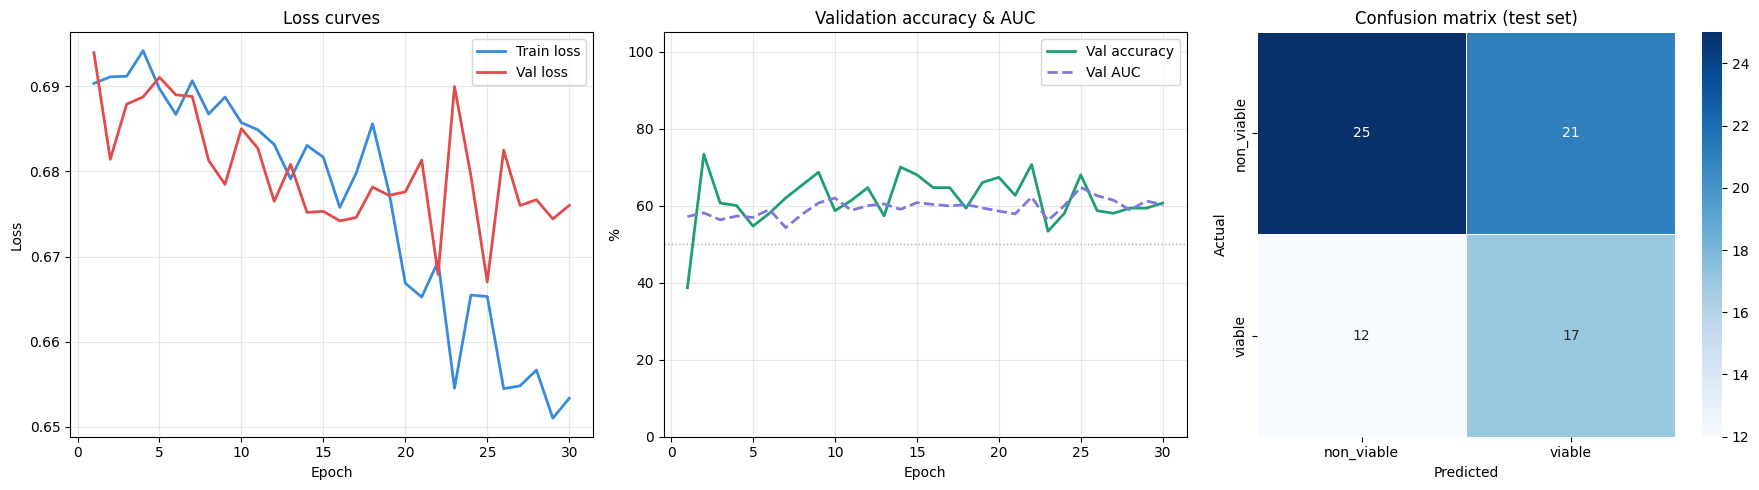

Saved → /content/drive/MyDrive/embryo_mae/classifier/training_metrics.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="white")
epochs_range = range(1, CFG.EPOCHS + 1)

# ── Loss curves ─────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_range, history["train_loss"], label="Train loss", color="#378ADD", lw=2)
ax.plot(epochs_range, history["val_loss"],   label="Val loss",   color="#E24B4A", lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss curves")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Val AUC over epochs ──────────────────────────────────────
ax = axes[1]
ax.plot(epochs_range, [a * 100 for a in history["val_acc"]], label="Val accuracy",
        color="#1D9E75", lw=2)
ax.plot(epochs_range, [a * 100 for a in history["val_auc"]], label="Val AUC",
        color="#7F77DD", lw=2, linestyle="--")
ax.axhline(50, color="#aaa", lw=1, linestyle=":")
ax.set_xlabel("Epoch")
ax.set_ylabel("%")
ax.set_title("Validation accuracy & AUC")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Confusion matrix ─────────────────────────────────────────
ax = axes[2]
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CFG.CLASSES, yticklabels=CFG.CLASSES,
    ax=ax, linewidths=0.5
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix (test set)")

plt.tight_layout()
plot_path = os.path.join(CFG.SAVE_DIR, "training_metrics.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot_path}")

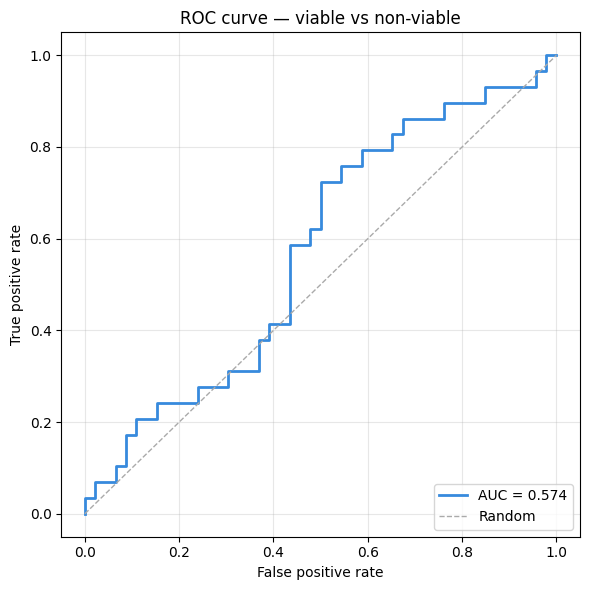

Saved → /content/drive/MyDrive/embryo_mae/classifier/roc_curve.png


In [ ]:
# ── ROC curve ────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)

fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.plot(fpr, tpr, color="#378ADD", lw=2, label=f"AUC = {test_auc:.3f}")
ax.plot([0, 1], [0, 1], color="#aaa", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — viable vs non-viable")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(CFG.SAVE_DIR, "roc_curve.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {roc_path}")

## 7. Predict on new images

In [ ]:
def predict_single(image_path, threshold=0.5):
    """
    Predict viability of a single embryo image.
    Returns: label, confidence, raw probabilities
    """
    model.eval()
    image = Image.open(image_path).convert("RGB")
    tensor = val_transform(image).unsqueeze(0).to(CFG.DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    viable_prob = probs[1]
    label       = CFG.CLASSES[1] if viable_prob >= threshold else CFG.CLASSES[0]
    confidence  = viable_prob if label == "viable" else 1 - viable_prob

    return label, confidence, probs


def predict_batch(image_paths, threshold=0.5):
    """Predict a list of image paths and show a summary grid."""
    results = []
    for path in image_paths:
        label, confidence, probs = predict_single(path, threshold)
        results.append((path, label, confidence, probs))

    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), facecolor="white")
    if n == 1:
        axes = [axes]

    for ax, (path, label, conf, probs) in zip(axes, results):
        img = Image.open(path).convert("RGB").resize((224, 224))
        ax.imshow(img)
        ax.axis("off")
        color = "#1D9E75" if label == "viable" else "#E24B4A"
        ax.set_title(
            f"{label}\n{conf*100:.1f}% confidence",
            color=color, fontweight="bold", fontsize=11
        )

    plt.tight_layout()
    plt.show()
    return results


# ── Example usage ────────────────────────────────────────────
# Swap in the actual paths you want to test
# test_images = [
#     "/content/drive/MyDrive/AI-Embryo/new_embryos/sample1.jpg",
#     "/content/drive/MyDrive/AI-Embryo/new_embryos/sample2.jpg",
# ]
# results = predict_batch(test_images)

# Or predict just one:
# label, confidence, probs = predict_single("path/to/embryo.jpg")
# print(f"Prediction: {label}  |  Viable probability: {probs[1]*100:.1f}%")

print("predict_single() and predict_batch() are ready to use.")

predict_single() and predict_batch() are ready to use.


## 8. Save final classifier

In [ ]:
final_path = os.path.join(CFG.SAVE_DIR, "embryo_viability_classifier.pth")
torch.save({
    "head_state_dict"    : model.head.state_dict(),
    "encoder_path"       : CFG.ENCODER_PATH,
    "classes"            : CFG.CLASSES,
    "best_val_auc"       : best_val_auc,
    "test_acc"           : test_acc,
    "test_auc"           : test_auc,
}, final_path)

print("══════════════════════════════════════")
print("  CLASSIFIER SAVED")
print("══════════════════════════════════════")
print(f"  Path     : {final_path}")
print(f"  Classes  : {CFG.CLASSES}")
print(f"  Test acc : {test_acc*100:.1f}%")
print(f"  Test AUC : {test_auc:.4f}")
print()
print("To reload later:")
print("  ckpt = torch.load(final_path)")
print("  model.head.load_state_dict(ckpt['head_state_dict'])")

══════════════════════════════════════
  CLASSIFIER SAVED
══════════════════════════════════════
  Path     : /content/drive/MyDrive/embryo_mae/classifier/embryo_viability_classifier.pth
  Classes  : ['non_viable', 'viable']
  Test acc : 56.0%
  Test AUC : 0.5742

To reload later:
  ckpt = torch.load(final_path)
  model.head.load_state_dict(ckpt['head_state_dict'])
